<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


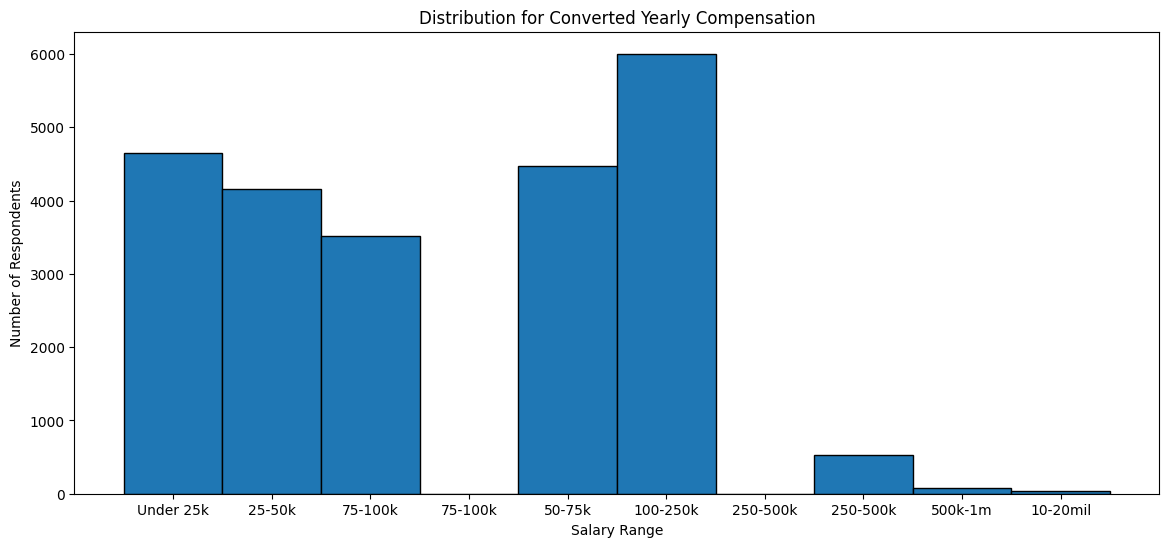

In [3]:
bins = [0, 25000, 50000, 75000, 100000, 250000, 500000, 1000000, 20000000]
labels = ['Under 25k', '25-50k', '50-75k', '75-100k', '100-250k', '250-500k', '500k-1m', '10-20mil']
ccy_hist = pd.cut(df['ConvertedCompYearly'], bins = bins, labels= labels, include_lowest = True)
ccy_hist = ccy_hist.dropna()

plt.figure(figsize=(14,6))
n, bins, patches = plt.hist(ccy_hist, align='mid', edgecolor = 'black')
plt.xlabel('Salary Range', ha='center')
bin_centers = (bins[:-1] + bins[1:]) / 2 # find the center of the bins
plt.xticks(bin_centers)
plt.ylabel('Number of Respondents')
plt.title('Distribution for Converted Yearly Compensation')
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [4]:
df_ft = df[df['Employment'] == 'Employed, full-time']
df_ft['ConvertedCompYearly'].mean()

np.float64(88921.1131013306)

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



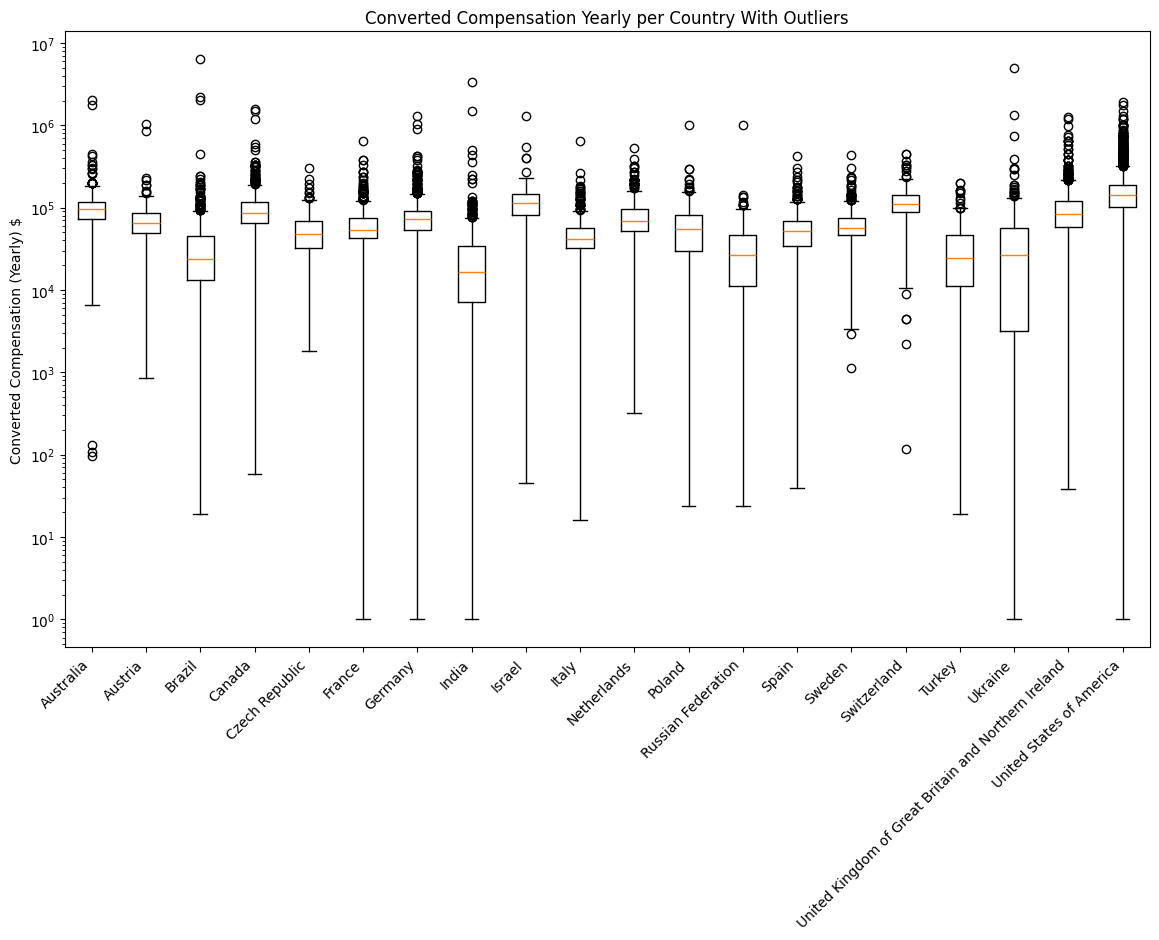

In [5]:
top_countries = df['Country'].value_counts().head(20).index # create list of the 20 countries with the most responses
df_topc = df[['Country', 'ConvertedCompYearly']] # create new dataframe with only pertinant columns
df_topc = df_topc.dropna() # drop NaN values
df_topc = df_topc[df_topc['Country'].isin(top_countries)] # keep data only pertaining to the 20 countries
grouped = df_topc.groupby('Country')['ConvertedCompYearly'] # create a group object for plotting

plt.figure(figsize=(14,8))
plt.boxplot(x=[group.values for name, group in grouped],
           tick_labels=grouped.groups.keys())
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.ylabel('Converted Compensation (Yearly) $')
plt.title('Converted Compensation Yearly per Country With Outliers')
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


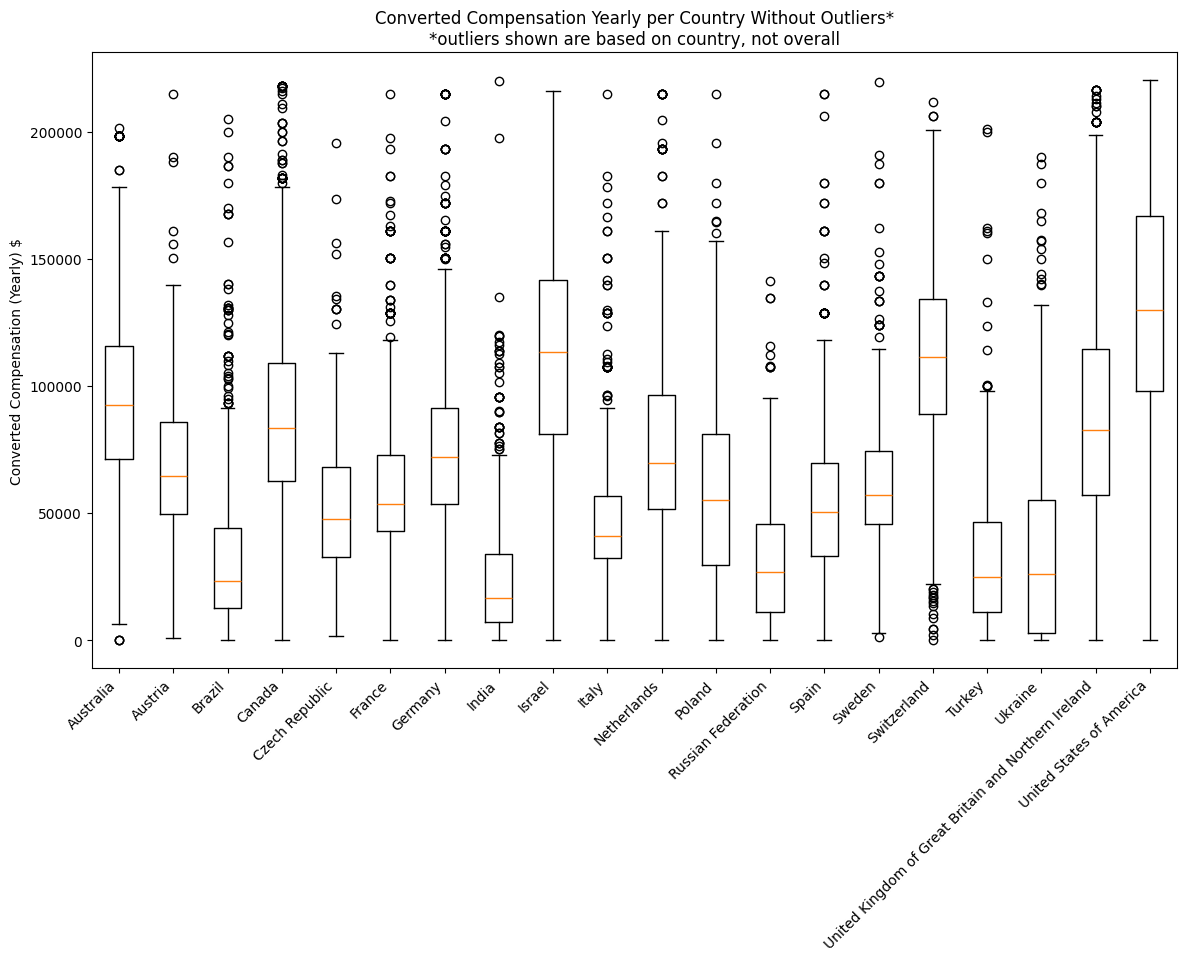

Q1:32712.0
Q3:107971.5
IQR:75259.5
Upper Bounds:220860.75
Lower Bounds:-80177.25


In [6]:
ccy_no_outliers = df[['Country', 'ConvertedCompYearly']]
ccy_no_outliers = ccy_no_outliers.dropna()

q1 = ccy_no_outliers['ConvertedCompYearly'].quantile(0.25)
q3 = ccy_no_outliers['ConvertedCompYearly'].quantile(0.75)
iqr = q3 - q1
upper_bounds = q3 + iqr * 1.5
lower_bounds = q1 - iqr * 1.5

ccy_no_outliers = df[['Country', 'ConvertedCompYearly']][(df['ConvertedCompYearly'] > lower_bounds) & (df['ConvertedCompYearly'] < upper_bounds)]

ccy_no_outliers = ccy_no_outliers[ccy_no_outliers['Country'].isin(top_countries)] # keep data only pertaining to the 20 countries
grouped_no_outliers = ccy_no_outliers.groupby('Country')['ConvertedCompYearly'] # create a group object for plotting

plt.figure(figsize=(14,8))
plt.boxplot(x=[group.values for name, group in grouped_no_outliers],
           tick_labels=grouped_no_outliers.groups.keys())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Converted Compensation (Yearly) $')
plt.title('Converted Compensation Yearly per Country Without Outliers*\n*outliers shown are based on country, not overall')
plt.show()
print(f'Q1:{q1}\nQ3:{q3}\nIQR:{iqr}\nUpper Bounds:{upper_bounds}\nLower Bounds:{lower_bounds}')

In [7]:
ccy_no_outliers.describe()

,ConvertedCompYearly
count,17089.000000
mean,78528.378431
std,52085.495322
min,1.000000
25%,39740.000000
50%,70000.000000
75%,110000.000000
max,220207.000000


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [8]:
df_ccy_we_jobsat = df[['WorkExp', 'JobSatPoints_1', 'ConvertedCompYearly']][(df['ConvertedCompYearly'] > lower_bounds) & (df['ConvertedCompYearly'] < upper_bounds)]
df_ccy_we_jobsat['JobSatPoints_1'] = df_ccy_we_jobsat['JobSatPoints_1'].ffill().bfill()
df_ccy_we_jobsat['WorkExp'] = df_ccy_we_jobsat['WorkExp'].fillna(df_ccy_we_jobsat['WorkExp'].mean())
df_ccy_we_jobsat.info()

<class 'pandas.DataFrame'>
Index: 22457 entries, 72 to 41186
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   WorkExp              22457 non-null  float64
 1   JobSatPoints_1       22457 non-null  float64
 2   ConvertedCompYearly  22457 non-null  float64
dtypes: float64(3)
memory usage: 701.8 KB


In [9]:
df_ccy_we_jobsat.corr()

,WorkExp,JobSatPoints_1,ConvertedCompYearly
WorkExp,1.000000,-0.026305,0.338850
JobSatPoints_1,-0.026305,1.000000,-0.042791
ConvertedCompYearly,0.338850,-0.042791,1.000000


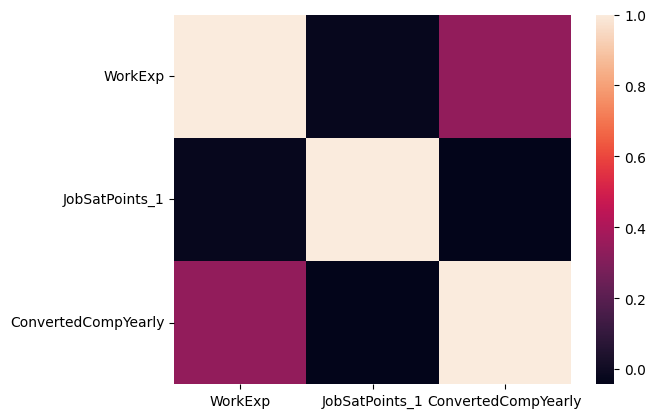

In [10]:
sns.heatmap(data = df_ccy_we_jobsat.corr())
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


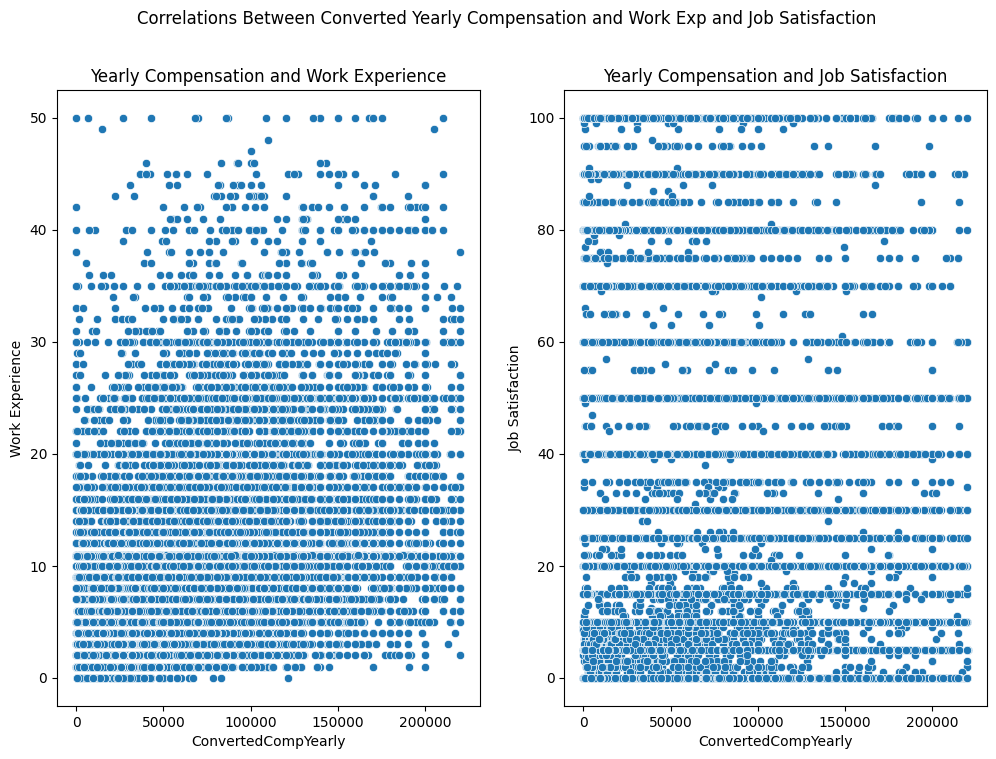

In [11]:
fig, axes = plt.subplots(1, 2, figsize = (12, 8))
sns.scatterplot(data = df_ccy_we_jobsat, x='ConvertedCompYearly', y='WorkExp', ax = axes[0])
sns.scatterplot(data = df_ccy_we_jobsat, x='ConvertedCompYearly', y='JobSatPoints_1', ax = axes[1])
axes[0].set_title('Yearly Compensation and Work Experience')
axes[0].set_ylabel('Work Experience')
axes[1].set_title('Yearly Compensation and Job Satisfaction')
axes[1].set_ylabel('Job Satisfaction')
plt.suptitle('Correlations Between Converted Yearly Compensation and Work Exp and Job Satisfaction')
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
